WEEK 1: Loading Dataset
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  31-07-2015   5263        555     1      1            0   
1      2          5  31-07-2015   6064        625     1      1            0   
2      3          5  31-07-2015   8314        821     1      1            0   
3      4          5  31-07-2015  13995       1498     1      1            0   
4      5          5  31-07-2015   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   

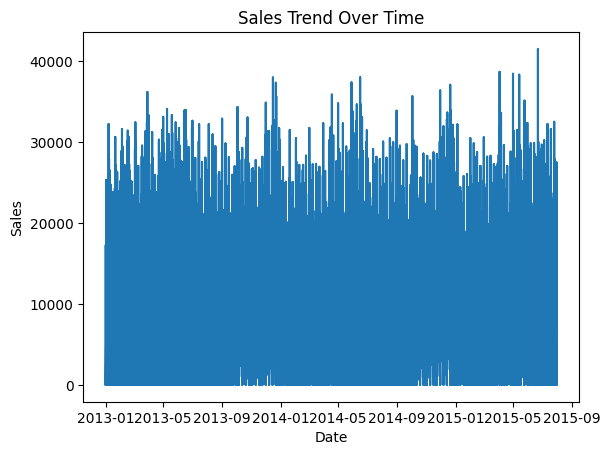


WEEK 4: Regression Models

Linear Regression
MAE: 2605.503744710037
RMSE: 3404.390943840199

Ridge Regression
MAE: 2605.5037415890615
RMSE: 3404.3909440982598

XGBoost
MAE: 1686.5958251953125
RMSE: 2556.8000508448054

WEEK 5: ARIMA Model

ARIMA Forecast (Next 30 Days):
1017209    8495.089004
1017210    8611.125608
1017211    8504.490958
1017212    8153.780962
1017213    8219.421103
1017214    7885.767373
1017215    8306.919825
1017216    8284.602946
1017217    8226.330097
1017218    8179.397705
1017219    8181.029695
1017220    8178.666437
1017221    8226.024933
1017222    8213.203678
1017223    8200.687061
1017224    8196.289683
1017225    8199.113694
1017226    8202.526246
1017227    8206.331235
1017228    8203.063431
1017229    8201.293302
1017230    8201.401366
1017231    8202.285697
1017232    8202.846292
1017233    8202.873029
1017234    8202.291867
1017235    8202.156877
1017236    8202.306539
1017237    8202.463017
1017238    8202.493314
Name: predicted_mean, dtype: float64

W

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


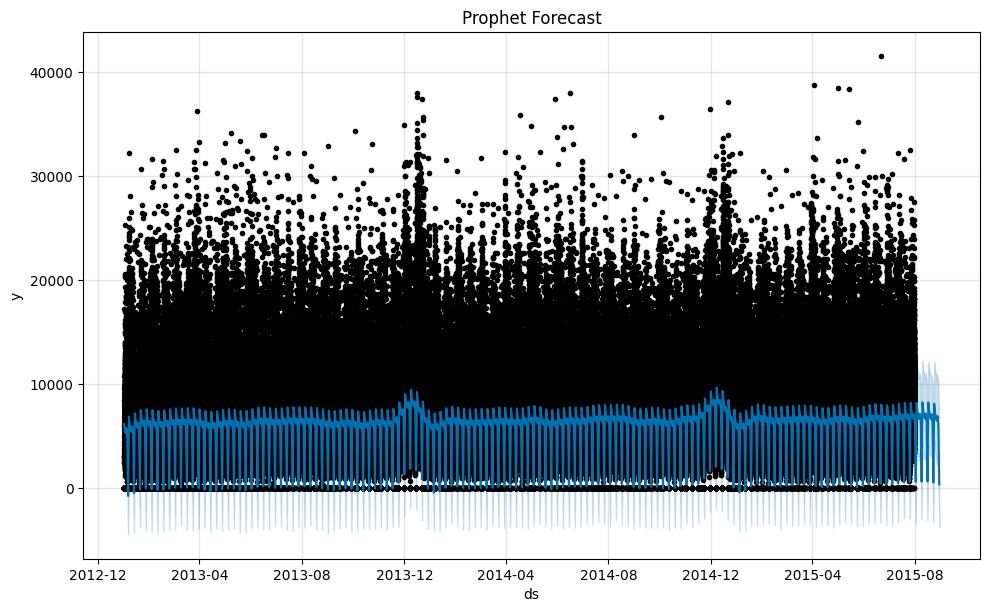


WEEK 7: Dashboard Code Ready
Run this separately in local system:
streamlit run your_file_name.py

PROJECT COMPLETED SUCCESSFULLY
✔ Data Loaded & Cleaned
✔ EDA Completed
✔ Regression Models Built
✔ ARIMA Forecast Done
✔ Prophet Forecast Done
✔ Dashboard Ready


In [ ]:
  # ==========================================================
# RETAIL SALES FORECASTING (WEEK 1 → WEEK 8 FINAL)
# ==========================================================

# ===============================
# INSTALL (ONLY FOR COLAB)
# ===============================
!pip install prophet xgboost --quiet

# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")


# ===============================
# WEEK 1 – LOAD & EXPLORE DATA
# ===============================
print("WEEK 1: Loading Dataset")

df = pd.read_csv("train.csv", low_memory=False)

print(df.head())
print(df.info())


# ===============================
# WEEK 2 – DATA PREPROCESSING
# ===============================
print("\nWEEK 2: Preprocessing")

df['Date'] = pd.to_datetime(df['Date'])

# Fix mixed datatype warning
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

df = df.sort_values('Date')
df.fillna(method='ffill', inplace=True)

# Feature Engineering
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['weekday'] = df['Date'].dt.weekday

print("Preprocessing Done")


# ===============================
# WEEK 3 – EDA
# ===============================
print("\nWEEK 3: Visualization")

plt.figure()
plt.plot(df['Date'], df['Sales'])
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


# ===============================
# WEEK 4 – REGRESSION MODELS
# ===============================
print("\nWEEK 4: Regression Models")

features = ['year', 'month', 'day', 'weekday']
X = df[features]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
evaluate("Linear Regression", y_test, lr.predict(X_test))

# Ridge Regression
ridge = Ridge()
ridge.fit(X_train, y_train)
evaluate("Ridge Regression", y_test, ridge.predict(X_test))

# XGBoost
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
evaluate("XGBoost", y_test, xgb.predict(X_test))


# ===============================
# WEEK 5 – ARIMA MODEL
# ===============================
print("\nWEEK 5: ARIMA Model")

df_arima = df[['Date', 'Sales']].copy()
df_arima.set_index('Date', inplace=True)

arima_model = ARIMA(df_arima['Sales'], order=(5,1,0))
arima_fit = arima_model.fit()

forecast_arima = arima_fit.forecast(steps=30)

print("\nARIMA Forecast (Next 30 Days):")
print(forecast_arima)


# ===============================
# WEEK 6 – PROPHET MODEL
# ===============================
print("\nWEEK 6: Prophet Model")

prophet_df = df[['Date', 'Sales']].copy()
prophet_df.columns = ['ds', 'y']

prophet_model = Prophet()
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=30)
forecast = prophet_model.predict(future)

prophet_model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()


# ===============================
# WEEK 7 – STREAMLIT (OPTIONAL)
# ===============================
print("\nWEEK 7: Dashboard Code Ready")

def run_dashboard():
    import streamlit as st
    st.title("Retail Sales Forecast Dashboard")
    st.write(df.head())
    st.line_chart(df['Sales'])

print("Run this separately in local system:")
print("streamlit run your_file_name.py")


# ===============================
# WEEK 8 – FINAL OUTPUT
# ===============================
print("\n====================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("====================================")

print("✔ Data Loaded & Cleaned")
print("✔ EDA Completed")
print("✔ Regression Models Built")
print("✔ ARIMA Forecast Done")
print("✔ Prophet Forecast Done")
print("✔ Dashboard Ready")